## Day 6 Hands on Lab Practice
Quick columnar-vs-row format benchmark (Parquet vs. CSV) for an analytical query; then a guided, time-boxed tour of a pre-built Docker Compose lakehouse stack (Spark + Delta Lake + MinIO + Hive Metastore) — write one Delta table to MinIO and query it back. (Wiring in real OSS Unity Catalog in place of Hive Metastore is an optional stretch goal, not required today.)

### Understanding the Docker compose Lakehouse Stack
- Docker compose lakehouse stack is a small, local version of a data lakehouse that allows us to run several data-engineering services together in our device using Docker Compose

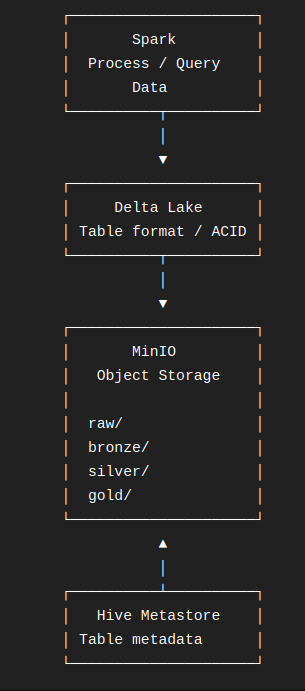

#### What Does Each Component Do ?

1. **MinIO**

- Stores the actual data 
- It is an object storage system (replicating a cloud object storage), think of it as a local S3 service
- Used to store parquet files physically on the device

2. **Spark** 

- Processes the data in a distributed manner

    - Reads the data from MinIO \
    - Creates a logical plan \
    - Optimizes the plan \
    - Executes tasks \
    - Produces the result \

3. **Delta Lake**

- Makes files behave like tables
- Bascially converts the unstructured format present in the Object storage into a table like format
- It adds a table layer on top of the files
- This gives your capabilities such as:
        - ACID transactions
        - schema enforcement
        - schema evolution
        - updates
        - deletes
        - time travel
        - version history

4. **Hive Metastore**

- It stores table metadata
- This keeps track of the transactions and states of the tables created by delta Lake


## NOTE : Github repo for docker componse lakehouse is not working due to image expiration 

- I have Setup custom Minio server

### Step 1: Setup Spark Session

In [15]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Day06_handsOnLab")
    .master("local[*]")
    .getOrCreate()
)

In [16]:
spark

### Step 2: Generate Analytical Dataset

In [17]:
from pyspark.sql.functions import (
    rand,
    floor,
    round,
    date_add,
    lit,
    when,
    col
)
# Number of rows
N = 1_000_000

# Generate base DataFrame

df = (
    spark.range(N)
    .withColumn("trip_id" , col("id"))
    .drop("id")
)


# Add Analytical columns to it

df = (
    df
    .withColumn(
        "trip_date",
        date_add(lit("2025-01-01"), floor(rand(seed=1) * 365).cast("int"))
    )
    .withColumn(
        "city",
        when((col("trip_id") % 5) == 0, "Kathmandu")
        .when((col("trip_id") % 5) == 1, "Pokhara")
        .when((col("trip_id") % 5) == 2, "Lalitpur")
        .when((col("trip_id") % 5) == 3, "Bhaktapur")
        .otherwise("Biratnagar")
    )
    .withColumn(
        "vehicle_type",
        when((col("trip_id") % 3) == 0, "Car")
        .when((col("trip_id") % 3) == 1, "Bike")
        .otherwise("Taxi")
    )
    .withColumn(
        "distance_km",
        round(rand(seed=2) * 30 + 1, 2)
    )
    .withColumn(
        "fare",
        round(rand(seed=3) * 1500 + 100, 2)
    )
    .withColumn(
        "driver_id",
        (rand(seed=4) * 10000).cast("int")
    )
    .withColumn(
        "passenger_count",
        (rand(seed=5) * 4 + 1).cast("int")
    )
    .withColumn(
        "payment_method",
        when((col("trip_id") % 3) == 0, "Cash")
        .when((col("trip_id") % 3) == 1, "Card")
        .otherwise("Digital")
    )
    .withColumn(
        "pickup_lat",
        round(rand(seed=6) * 0.5 + 27.5, 6)
    )
    .withColumn(
        "pickup_lon",
        round(rand(seed=7) * 0.5 + 85.2, 6)
    )
    .withColumn(
        "dropoff_lat",
        round(rand(seed=8) * 0.5 + 27.5, 6)
    )
    .withColumn(
        "dropoff_lon",
        round(rand(seed=9) * 0.5 + 85.2, 6)
    )
    .withColumn(
        "weather",
        when((col("trip_id") % 3) == 0, "Sunny")
        .when((col("trip_id") % 3) == 1, "Cloudy")
        .otherwise("Rainy")
    )
    .withColumn(
        "traffic_level",
        when((col("trip_id") % 3) == 0, "Low")
        .when((col("trip_id") % 3) == 1, "Medium")
        .otherwise("High")
    )
)


In [18]:
df.printSchema()

root
 |-- trip_id: long (nullable = false)
 |-- trip_date: date (nullable = true)
 |-- city: string (nullable = false)
 |-- vehicle_type: string (nullable = false)
 |-- distance_km: double (nullable = true)
 |-- fare: double (nullable = true)
 |-- driver_id: integer (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- payment_method: string (nullable = false)
 |-- pickup_lat: double (nullable = true)
 |-- pickup_lon: double (nullable = true)
 |-- dropoff_lat: double (nullable = true)
 |-- dropoff_lon: double (nullable = true)
 |-- weather: string (nullable = false)
 |-- traffic_level: string (nullable = false)



In [19]:
df.show(5, truncate=False)

+-------+----------+----------+------------+-----------+-------+---------+---------------+--------------+----------+----------+-----------+-----------+-------+-------------+
|trip_id|trip_date |city      |vehicle_type|distance_km|fare   |driver_id|passenger_count|payment_method|pickup_lat|pickup_lon|dropoff_lat|dropoff_lon|weather|traffic_level|
+-------+----------+----------+------------+-----------+-------+---------+---------------+--------------+----------+----------+-----------+-----------+-------+-------------+
|0      |2025-08-21|Kathmandu |Car         |16.93      |486.07 |9531     |1              |Cash          |27.535199 |85.340941 |27.741825  |85.557284  |Sunny  |Low          |
|1      |2025-08-07|Pokhara   |Bike        |9.58       |1104.83|661      |1              |Card          |27.868102 |85.429994 |27.867108  |85.433109  |Cloudy |Medium       |
|2      |2025-02-19|Lalitpur  |Taxi        |15.83      |1512.5 |1445     |4              |Digital       |27.742247 |85.584549 |27.

In [20]:
# Materialize the dataset once
df.cache()
print("Row count:", df.count())

# Save as Parquet
df.write.mode("overwrite").parquet("data/trips_parquet")

# Save as CSV
df.write.mode("overwrite").option("header", True).csv("data/trips_csv")

print("Finished writing CSV and Parquet datasets.")



Row count: 1000000


26/09/25 10:17:10 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/09/25 10:17:10 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/09/25 10:17:10 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/09/25 10:17:10 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/09/25 10:17:10 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 63.33% for 12 writers
26/09/25 10:17:10 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 58.46% for 13 writers
26/09/25 10:17:10 WARN MemoryManager: Total allocation exceeds 95.

Finished writing CSV and Parquet datasets.


### Step 3: Inspect Parquet and CSV contents

### 3.1: Checking the Csv and parquet total content size

In [21]:
ls -lh data/


total 8.0K
drwxr-xr-x 2 leapfrog leapfrog 4.0K Sep 25 10:17 trips_csv/
drwxr-xr-x 2 leapfrog leapfrog 4.0K Sep 25 10:17 trips_parquet/


In [22]:
ls -lh data/trips_parquet/

total 45M
-rw-r--r-- 1 leapfrog leapfrog 2.8M Sep 25 10:17 part-00000-c1cad795-6400-4cbb-91d4-a2d73b6a9986-c000.snappy.parquet
-rw-r--r-- 1 leapfrog leapfrog 2.8M Sep 25 10:17 part-00001-c1cad795-6400-4cbb-91d4-a2d73b6a9986-c000.snappy.parquet
-rw-r--r-- 1 leapfrog leapfrog 2.8M Sep 25 10:17 part-00002-c1cad795-6400-4cbb-91d4-a2d73b6a9986-c000.snappy.parquet
-rw-r--r-- 1 leapfrog leapfrog 2.8M Sep 25 10:17 part-00003-c1cad795-6400-4cbb-91d4-a2d73b6a9986-c000.snappy.parquet
-rw-r--r-- 1 leapfrog leapfrog 2.8M Sep 25 10:17 part-00004-c1cad795-6400-4cbb-91d4-a2d73b6a9986-c000.snappy.parquet
-rw-r--r-- 1 leapfrog leapfrog 2.8M Sep 25 10:17 part-00005-c1cad795-6400-4cbb-91d4-a2d73b6a9986-c000.snappy.parquet
-rw-r--r-- 1 leapfrog leapfrog 2.8M Sep 25 10:17 part-00006-c1cad795-6400-4cbb-91d4-a2d73b6a9986-c000.snappy.parquet
-rw-r--r-- 1 leapfrog leapfrog 2.8M Sep 25 10:17 part-00007-c1cad795-6400-4cbb-91d4-a2d73b6a9986-c000.snappy.parquet
-rw-r--r-- 1 leapfrog leapfrog 2.8M Sep 25 10:17 part-

In [23]:
ls -lh data/trips_csv/

total 105M
-rw-r--r-- 1 leapfrog leapfrog 6.5M Sep 25 10:17 part-00000-3fa28dd2-1f44-4d90-b352-7d561d0e46d4-c000.csv
-rw-r--r-- 1 leapfrog leapfrog 6.5M Sep 25 10:17 part-00001-3fa28dd2-1f44-4d90-b352-7d561d0e46d4-c000.csv
-rw-r--r-- 1 leapfrog leapfrog 6.6M Sep 25 10:17 part-00002-3fa28dd2-1f44-4d90-b352-7d561d0e46d4-c000.csv
-rw-r--r-- 1 leapfrog leapfrog 6.6M Sep 25 10:17 part-00003-3fa28dd2-1f44-4d90-b352-7d561d0e46d4-c000.csv
-rw-r--r-- 1 leapfrog leapfrog 6.6M Sep 25 10:17 part-00004-3fa28dd2-1f44-4d90-b352-7d561d0e46d4-c000.csv
-rw-r--r-- 1 leapfrog leapfrog 6.6M Sep 25 10:17 part-00005-3fa28dd2-1f44-4d90-b352-7d561d0e46d4-c000.csv
-rw-r--r-- 1 leapfrog leapfrog 6.6M Sep 25 10:17 part-00006-3fa28dd2-1f44-4d90-b352-7d561d0e46d4-c000.csv
-rw-r--r-- 1 leapfrog leapfrog 6.6M Sep 25 10:17 part-00007-3fa28dd2-1f44-4d90-b352-7d561d0e46d4-c000.csv
-rw-r--r-- 1 leapfrog leapfrog 6.6M Sep 25 10:17 part-00008-3fa28dd2-1f44-4d90-b352-7d561d0e46d4-c000.csv
-rw-r--r-- 1 leapfrog leapfrog 6.6M

In [24]:
!du -sh data/trips_csv data/trips_parquet

106M	data/trips_csv
45M	data/trips_parquet


In [25]:
!du -sb data/trips_csv data/trips_parquet

110024141	data/trips_csv
46864424	data/trips_parquet


### Deduction 1: Parquet Files takes less space to store

- We can see that parquet takes 45MB wher eas CSV takes 106MB

### 3.2: Counting the actual  data files

In [26]:
!find data/trips_csv -type f -name "*.csv" | wc -l

16


In [27]:
!find data/trips_parquet/ -type f -name "*.parquet" | wc -l

16


### Step 4: Analyzing querying on csv and parquet

In [32]:
import os

# Load CSV data

print("----------- CSV Dataframe ---------------")

csv_df = spark.read.csv(
     "data/trips_csv",
    header=True,
    inferSchema=True
)


csv_df.show(5)

# Load Parquet Data

print("----------- Parquet Dataframe ---------------")


parquet_df = spark.read.parquet(
    "data/trips_parquet",
)

parquet_df.show(5)


----------- CSV Dataframe ---------------


+-------+----------+----------+------------+-----------+-------+---------+---------------+--------------+----------+----------+-----------+-----------+-------+-------------+
|trip_id| trip_date|      city|vehicle_type|distance_km|   fare|driver_id|passenger_count|payment_method|pickup_lat|pickup_lon|dropoff_lat|dropoff_lon|weather|traffic_level|
+-------+----------+----------+------------+-----------+-------+---------+---------------+--------------+----------+----------+-----------+-----------+-------+-------------+
| 875000|2025-03-08| Kathmandu|        Taxi|      15.88|1554.62|     3408|              2|       Digital| 27.799836| 85.519807|  27.760626|  85.669402|  Rainy|         High|
| 875001|2025-08-17|   Pokhara|         Car|       6.05| 212.96|     7765|              2|          Cash| 27.782459| 85.235111|  27.737889|  85.520613|  Sunny|          Low|
| 875002|2025-05-10|  Lalitpur|        Bike|       4.93| 178.64|      981|              2|          Card| 27.969439| 85.355164|  2

In [ ]:
from pyspark.sql.functions import sum, avg

# Analytical Query

def run_query(df, name):

    print(f"\n ===== {name} =====")

    result = (
        df
        .filter(
            (col("trip_date") >= "2025-01-01") &
            (col("trip_date") < "2025-02-01")
        )
        .groupBy("city")
        .agg(
            sum("fare").alias("total_fare"),
            avg("distance_km").alias("avg_distance")
        )
    )

    result.show()
